In [16]:
import h5py
import os
import re

folder = "results"   # your results folder
all_data = {}        # keyed by (snr, nspec)

for filename in os.listdir(folder):
    if filename.startswith("barnard_o20"):
        filepath = os.path.join(folder, filename)
        print(filepath)
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

            # RV Samples
            rv_group = f['Order']['Observational Parameters']['RV Samples']
            rv_analysis = {
                seed: {subname: subdset[:] for subname, subdset in seed_group.items()}
                for seed, seed_group in rv_group.items()
            }

            # Store under (snr, nspec, step)
            all_data[(i, snr, nspec)] = {
                "spectrum": spectrum_analysis,
                "rv": rv_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]

results/barnard_o20_i0_snr50_nspec10.h5


# Basic code to plot the spectra

Text(0, 0.5, 'Normalized Flux')

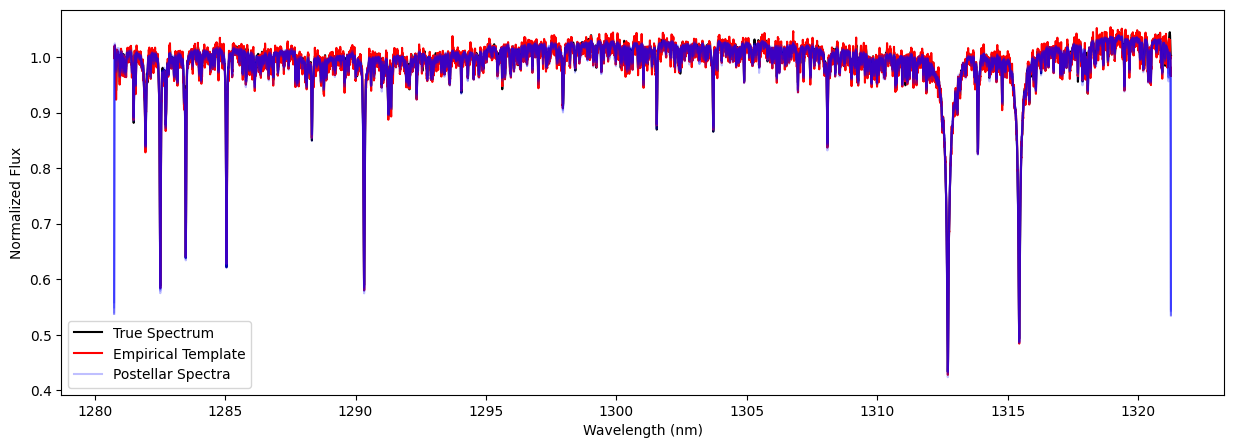

In [17]:
import matplotlib.pylab as plt
i = 0
snr = 50
nspec = 10
spectra = all_data[(i,snr,nspec)]['spectrum']

##
# If you used the phoenix models then you have to include the non_ones index when plotting 
# as well ie spectra['true_spectrum'][0,0,non_ones]
##

plt.figure(figsize=(15,5))
plt.plot(wgrid,spectra['true_spectrum'][0,0],c="k",label="True Spectrum")
plt.plot(wgrid,spectra['template'],c='r',label="Empirical Template")
for j in range(len(spectra['posterior_spectrum_samples'][0])):
    if j ==0:
        plt.plot(wgrid,spectra['posterior_spectrum_samples'][0,j,0,non_ones],alpha=0.25,c='b',label='Postellar Spectra')
    else:  
        plt.plot(wgrid,spectra['posterior_spectrum_samples'][0,j,0,non_ones],alpha=0.25,c='b')
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Flux")

Play around with zooming into different features to see which spectrum does better at representing the true spectrum.

# Basic Code to Plot the RVs

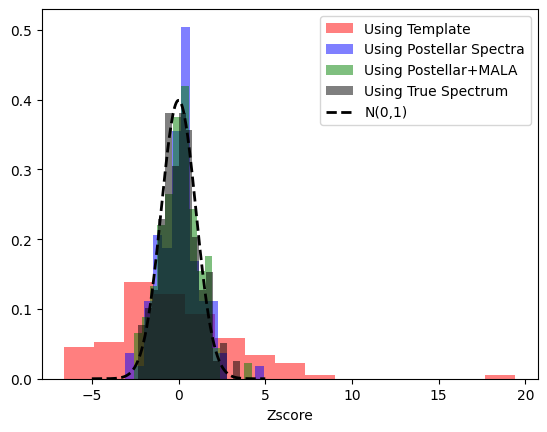

In [18]:
import numpy as np
from scipy.stats import norm

rvs = all_data[(i,snr,nspec)]['rv']
# Lets just look at one noise instance, rather than averaging across multiple noise instances
rvs = rvs['seed_0']

# Let's create Zscores (this evaluates how reliable our RVs are from the different methods)
# The histogram of zscore should look like a normal distribution (centered at 0, with a standard deviation of 1)
intrinsic_zscore = (rvs['intrinsic_rv']-rvs['true_planet'])/rvs['intrinsic_uncertainty']
template_zscore = (rvs['template_rv']-rvs['true_planet'])/rvs['template_uncertainty']
postellar_zscore = (rvs['prior_rv']-rvs['true_planet'])/rvs['prior_uncertainty']

mala_rv = np.zeros(len(rvs['true_planet']))
mala_unc = np.zeros(len(rvs['true_planet']))
result = rvs['mala_samples'].transpose(2, 0, 1)
for k,samples in enumerate(result):
    mala_rv[k] = np.mean(samples)
    mala_unc[k]= np.std(samples)
mala_zscores = (mala_rv-rvs['true_planet'])/mala_unc
plt.hist(template_zscore,alpha=0.5,color='r',label='Using Template',bins=15,density=True)
plt.hist(postellar_zscore,alpha=0.5,color='b',label='Using Postellar Spectra',bins=15,density=True)
plt.hist(mala_zscores,alpha=0.5,color='g',label='Using Postellar+MALA',bins=15,density=True)
plt.hist(intrinsic_zscore,alpha=0.5,color='k',label='Using True Spectrum',bins=15,density=True)
# Overplot standard normal
x = np.linspace(-5, 5, 200)
plt.plot(x, norm.pdf(x), 'k--', label='N(0,1)', lw=2)

plt.xlabel("Zscore")
plt.legend()

From the figure above we should see that the postellar RVs are closer to the normal distribution than the template RVs, which means the RVs retrieved with postellar are more reliable

# Sanity Check
The uncertainty from using the intrinsic spectrum should be similar to the fundamental Bouchy uncertainty. Read Bouchy 2001 for more info.

In [20]:
import sys
sys.path.append("../src")
from transformer import *
from scipy.interpolate import InterpolatedUnivariateSpline
from astropy.constants import c

## Determine the average uncertainty value across all the trials that were computed
all_intrinsic_uncertainty = np.concatenate([
    seed_data["intrinsic_uncertainty"]
    for seed_data in all_data[(i,snr,nspec)]['rv'].values()
])
avg_unc = np.median(all_intrinsic_uncertainty)


# Calculate Bouchy Uncertainty

# First bring true spectrum into instrument sampling
real_spec = spectra['true_spectrum'][0,0]
spline = InterpolatedUnivariateSpline(wgrid,real_spec)
ys = spline(inst_wgrid)
start = int(0.005 * len(ys))
end = int(0.995 * len(ys))
A_0 = snr**2*ys[start:end]
Lambda = inst_wgrid[start:end]

# Compute the uncertainty
dAdlam = np.gradient(A_0,Lambda)
W = (Lambda*dAdlam)**2/A_0
Q = np.sqrt(np.sum(W))/np.sqrt(np.sum(A_0))
Ne = np.sum(A_0)

deltaV = c/(Q*np.sqrt(Ne))


print("The average uncertainty using a true spectrum measured is:", avg_unc)
print("The Bouchy uncertainty for this type of observation is", deltaV)

The average uncertainty using a true spectrum measured is: 50.52276182276756
The Bouchy uncertainty for this type of observation is 57.75661536190752 m / s
